<a href="https://colab.research.google.com/github/ErbolTakhirov/Learning-notebooks/blob/main/ML/Bishkek_comp/SGD_BISHKEK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

from sklearn.linear_model import SGDRegressor

In [ ]:
X_just = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/F/expirements/X_just_test_2.csv')
X_just.drop(X_just.columns[0], axis = 1, inplace = True)

In [ ]:
X_just.iloc[:, 0]

,square
0,113.80
1,66.00
2,68.00
3,135.00
4,67.00
...,...
7118,48.00
7119,89.00
7120,80.21
7121,145.30


In [ ]:
y = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/F/expirements/y.csv')
y.index = y.iloc[:, 0]
y.drop(y.columns[0], axis = 1, inplace = True)
y.index.name = 'index'
y

,usd_price
index,
0,157000
1,96500
2,108500
3,260000
4,103000
...,...
7129,87000
7130,155000
7131,104000


In [ ]:
X_just['age'] = 2025 - X_just['age']

<Axes: xlabel='age', ylabel='Count'>

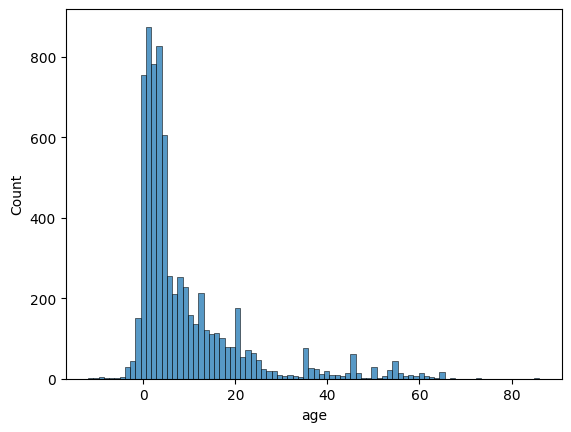

In [ ]:
sns.histplot(X_just['age'])

In [ ]:
X_just_2 = X_just.copy()
X_just_2.drop('floor_ratio', axis = 1, inplace = True)

In [ ]:
X_just_2['floor'] = X_just_2['floor'] + 0.5
X_just_2

,square,distance_am,series,rooms,house_type,year,inv_distance,age,floor
0,113.80,1.702601,индивид. планировка,3,кирпичный,8.0,0.370014,8.0,0.666667
1,66.00,7.037787,элитка,2,монолитный,2.0,0.124412,2.0,0.666667
2,68.00,6.519077,106 серия,3,кирпичный,35.0,0.132995,35.0,0.722222
3,135.00,4.643078,элитка,4,монолитный,3.0,0.177208,3.0,0.928571
4,67.00,1.864922,элитка,2,монолитный,2.0,0.349050,2.0,0.928571
...,...,...,...,...,...,...,...,...,...
7118,48.00,1.950375,105 серия,2,панельный,46.0,0.338940,46.0,0.833333
7119,89.00,4.651687,элитка,3,кирпичный,3.0,0.176938,3.0,0.714286
7120,80.21,2.508314,элитка,2,монолитный,0.0,0.285037,0.0,0.676471
7121,145.30,2.794541,индивид. планировка,3,монолитный,6.0,0.263536,6.0,0.500000


In [ ]:
X_just_2['series'].value_counts()

,count
series,
элитка,4771
индивид. планировка,959
104 серия,352
105 серия,303
106 серия,249
106 серия улучшенная,130
хрущевка,127
108 серия,90
105 серия улучшенная,37


In [ ]:
X_just_2

,square,distance_am,series,rooms,house_type,year,inv_distance,age,floor
0,113.80,1.702601,индивид. планировка,3,кирпичный,8.0,0.370014,8.0,0.666667
1,66.00,7.037787,элитка,2,монолитный,2.0,0.124412,2.0,0.666667
2,68.00,6.519077,106 серия,3,кирпичный,35.0,0.132995,35.0,0.722222
3,135.00,4.643078,элитка,4,монолитный,3.0,0.177208,3.0,0.928571
4,67.00,1.864922,элитка,2,монолитный,2.0,0.349050,2.0,0.928571
...,...,...,...,...,...,...,...,...,...
7118,48.00,1.950375,105 серия,2,панельный,46.0,0.338940,46.0,0.833333
7119,89.00,4.651687,элитка,3,кирпичный,3.0,0.176938,3.0,0.714286
7120,80.21,2.508314,элитка,2,монолитный,0.0,0.285037,0.0,0.676471
7121,145.30,2.794541,индивид. планировка,3,монолитный,6.0,0.263536,6.0,0.500000


In [ ]:
X_just_2['house_type'].value_counts()

,count
house_type,
монолитный,3844
кирпичный,2186
панельный,1093


In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 3.7 MB/s eta 0:00:00


In [ ]:
X_just_2.index= y.index

In [ ]:
from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder

# Разделяем на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_just_2, y, test_size=0.25, random_state=42  # стратификация по серии
)

# # Сбрасываем индексы после разделения - УДАЛЕНО
# X_train = X_train.reset_index(drop=True)
# X_test = X_test.reset_index(drop=True)
# y_train = y_train.reset_index(drop=True)
# y_test = y_test.reset_index(drop=True)


# Кодируем 'series' после разделения
encoder_series = TargetEncoder(cols=['series'])
X_train['series_encoded'] = encoder_series.fit_transform(X_train[['series']], y_train)['series']
X_test['series_encoded'] = encoder_series.transform(X_test[['series']])['series']

# Кодируем 'house_type' после разделения
encoder_house = TargetEncoder(cols=['house_type'])
X_train['house_type_encoded'] = encoder_house.fit_transform(X_train[['house_type']], y_train)['house_type']
X_test['house_type_encoded'] = encoder_house.transform(X_test[['house_type']])['house_type']

# Удаляем оригинальные столбцы 'series' и 'house_type'
X_train = X_train.drop(['series', 'house_type'], axis=1)
X_test = X_test.drop(['series', 'house_type'], axis=1)


print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"X_train columns: {X_train.columns.tolist()}")
print(f"X_test columns: {X_test.columns.tolist()}")

Train shape: (5342, 9)
Test shape: (1781, 9)
X_train columns: ['square', 'distance_am', 'rooms', 'year', 'inv_distance', 'age', 'floor', 'series_encoded', 'house_type_encoded']
X_test columns: ['square', 'distance_am', 'rooms', 'year', 'inv_distance', 'age', 'floor', 'series_encoded', 'house_type_encoded']


In [ ]:
X_train

,square,distance_am,rooms,year,inv_distance,age,floor,series_encoded,house_type_encoded
index,,,,,,,,,
7050,81.0,7.933479,3,8.0,0.111938,8.0,0.875000,119616.532105,121307.861082
5570,78.0,4.028210,2,0.0,0.198878,0.0,0.812500,119616.532105,121307.861082
1362,50.0,1.873757,2,18.0,0.347977,18.0,0.555556,119616.532105,121307.861082
418,126.4,2.312866,3,9.0,0.301853,9.0,0.600000,118517.094901,110591.836661
4331,59.0,3.359687,1,0.0,0.229374,0.0,0.714286,119616.532105,121307.861082
...,...,...,...,...,...,...,...,...,...
3776,70.0,8.418465,3,19.0,0.106174,19.0,0.722222,90190.731169,84160.440534
5198,48.0,5.063219,1,0.0,0.164929,0.0,0.937500,119616.532105,110591.836661
5233,48.0,3.479395,1,3.0,0.223244,3.0,0.944444,80579.757767,121307.861082


In [ ]:
X_train, y_train

(       square  distance_am  rooms  year  inv_distance   age     floor  \
 index                                                                   
 7050     81.0     7.933479      3   8.0      0.111938   8.0  0.875000   
 5570     78.0     4.028210      2   0.0      0.198878   0.0  0.812500   
 1362     50.0     1.873757      2  18.0      0.347977  18.0  0.555556   
 418     126.4     2.312866      3   9.0      0.301853   9.0  0.600000   
 4331     59.0     3.359687      1   0.0      0.229374   0.0  0.714286   
 ...       ...          ...    ...   ...           ...   ...       ...   
 3776     70.0     8.418465      3  19.0      0.106174  19.0  0.722222   
 5198     48.0     5.063219      1   0.0      0.164929   0.0  0.937500   
 5233     48.0     3.479395      1   3.0      0.223244   3.0  0.944444   
 5397     40.0     6.464085      1   4.0      0.133975   4.0  0.583333   
 860      70.0     4.986544      2   4.0      0.167041   4.0  0.611111   
 
        series_encoded  house_type_e

In [ ]:
from category_encoders import TargetEncoder

# Автоматически обрабатывает data leakage
encoder = TargetEncoder(cols=['series_encoded'])
X_train_encoded = encoder.fit_transform(X_train, y_train)
X_test_encoded = encoder.transform(X_test)

In [ ]:
X_test_encoded

,square,distance_am,rooms,year,inv_distance,age,floor,series_encoded,house_type_encoded
index,,,,,,,,,
3619,77.81,5.461700,2,5.0,0.154758,5.0,0.944444,119616.532105,110591.836661
2037,38.00,4.492374,1,39.0,0.182071,39.0,0.500000,78970.613375,84160.440534
1564,72.00,6.496984,2,4.0,0.133387,4.0,0.730769,119616.532105,121307.861082
4279,52.00,4.472933,2,16.0,0.182717,16.0,0.722222,119616.532105,121307.861082
6359,45.00,8.156693,2,20.0,0.109210,20.0,0.833333,118517.094901,110591.836661
...,...,...,...,...,...,...,...,...,...
1342,67.00,2.977368,2,4.0,0.251423,4.0,0.857143,119616.532105,121307.861082
3322,116.00,5.223267,3,4.0,0.160687,4.0,1.000000,119616.532105,121307.861082
5755,43.00,3.983227,2,20.0,0.200673,20.0,0.750000,76168.670330,84160.440534


In [ ]:
X_train_encoded

,square,distance_am,rooms,year,inv_distance,age,floor,series_encoded,house_type_encoded
index,,,,,,,,,
7050,81.0,7.933479,3,8.0,0.111938,8.0,0.875000,119616.532105,121307.861082
5570,78.0,4.028210,2,0.0,0.198878,0.0,0.812500,119616.532105,121307.861082
1362,50.0,1.873757,2,18.0,0.347977,18.0,0.555556,119616.532105,121307.861082
418,126.4,2.312866,3,9.0,0.301853,9.0,0.600000,118517.094901,110591.836661
4331,59.0,3.359687,1,0.0,0.229374,0.0,0.714286,119616.532105,121307.861082
...,...,...,...,...,...,...,...,...,...
3776,70.0,8.418465,3,19.0,0.106174,19.0,0.722222,90190.731169,84160.440534
5198,48.0,5.063219,1,0.0,0.164929,0.0,0.937500,119616.532105,110591.836661
5233,48.0,3.479395,1,3.0,0.223244,3.0,0.944444,80579.757767,121307.861082


In [ ]:
# encoder_house = TargetEncoder(cols=['house_type'])
# X_train['house_type_encoded'] = encoder_house.fit_transform(X_train[['house_type']], y_train)['house_type']
# X_test['house_type_encoded'] = encoder_house.transform(X_test[['house_type']])['house_type']

In [ ]:
X_train_encoded.dtypes

In [ ]:
# Посмотрим на текущие данные
print("Типы данных:")
print(X_train_encoded.dtypes)

print("\nУникальные значения series:")
print(X_train_encoded['series'].unique()[:10])  # первые 10 значений

print("\nУникальные значения house_type:")
print(X_train_encoded['house_type'].unique())

print("\nСтатистика по series:")
print(X_train_encoded['series'].describe())


In [ ]:
house_encoder = TargetEncoder(cols=['house_type'])
house_encoder

TargetEncoder(cols=['house_type'])

In [ ]:
# from category_encoders import TargetEncoder

# house_encoder = TargetEncoder(cols=['house_type'])

# # 4️⃣ Кодируем, сохраняя исходные индексы
# X_train_final = house_encoder.fit_transform(X_train.copy(), y_train)
# X_test_final = house_encoder.transform(X_test.copy())

# # 5️⃣ Удаляем оригинальный столбец house_type если остался
# if 'house_type' in X_train_final.columns and X_train_final['house_type'].dtype == 'object':
#     X_train_final = X_train_final.drop('house_type', axis=1)
#     X_test_final = X_test_final.drop('house_type', axis=1)

# # ✅ Проверка
# print("Готово!")
# print(f"X_train_final shape: {X_train_final.shape}")
# print(f"X_test_final shape: {X_test_final.shape}")
# print(f"Столбцы: {X_train_final.columns.tolist()}")

In [ ]:
# from category_encoders import TargetEncoder

# # Просто кодируем house_type и оставляем остальные фичи как есть
# house_encoder = TargetEncoder(cols=['house_type'])

# X_train_final = house_encoder.fit_transform(X_train, y_train)
# X_test_final = house_encoder.transform(X_test)

# # Удаляем оригинальный house_type если он остался как объект
# if 'house_type' in X_train_final.columns and X_train_final['house_type'].dtype == 'object':
#     X_train_final = X_train_final.drop('house_type', axis=1)
#     X_test_final = X_test_final.drop('house_type', axis=1)

# print("Готово!")
# print(f"X_train_final shape: {X_train_final.shape}")
# print(f"X_test_final shape: {X_test_final.shape}")
# print(f"Столбцы: {X_train_final.columns.tolist()}")

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Линейная регрессия
print("Настраиваем Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_encoded, np.log(y_train))
y_pred_lr = np.exp(lr.predict(X_test_encoded))
print(f"Linear Regression MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}")

# 2. Ridge регрессия с GridSearch
print("\nНастраиваем Ridge Regression...")
ridge = Ridge()
ridge_params = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
    'max_iter': [1000, 2000]
}

ridge_grid = GridSearchCV(ridge, ridge_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
ridge_grid.fit(X_train_encoded, np.log(y_train))

print(f"Лучшие параметры Ridge: {ridge_grid.best_params_}")
print(f"Лучший MAE Ridge: {-ridge_grid.best_score_:.2f}")

# 3. Lasso регрессия с GridSearch
print("\nНастраиваем Lasso Regression...")
lasso = Lasso()
lasso_params = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 3, 500],
    'max_iter': [1000, 2000]
}

lasso_grid = GridSearchCV(lasso, lasso_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
lasso_grid.fit(X_train_encoded, np.log(y_train))

best_lasso = lasso_grid.best_estimator_
y_pred_lasso = np.exp(best_lasso.predict(X_test_encoded))

# Преобразуем y_test в одномерный массив
y_true = np.ravel(y_test)  # или y_test.squeeze()

# Вычисляем MAPE (в %)
mape_lasso = np.mean(np.abs((y_true - y_pred_lasso) / y_true)) * 100

print(f"Лучшие параметры Lasso: {lasso_grid.best_params_}")
print(f"Лучший MAE Lasso: {-lasso_grid.best_score_:.2f}")
print(f"Лучший MAPE Lasso: {mape_lasso:.2f}%")

Настраиваем Linear Regression...


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- age
- house_type_encoded


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Линейная регрессия
print("Настраиваем Linear Regression...")
lr_ = LinearRegression()
lr_.fit(X_train_encoded, np.log(y_train))
y_pred_lr_ = np.exp(lr_.predict(X_test_encoded))
print(f"Linear Regression MAE: {mean_absolute_error(y_test, y_pred_lr_):.2f}")

# 2. Ridge регрессия с GridSearch
print("\nНастраиваем Ridge Regression...")
ridge = Ridge()
ridge_params = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
    'max_iter': [1000, 2000]
}

ridge_grid = GridSearchCV(ridge, ridge_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
ridge_grid.fit(X_train_encoded, np.log(y_train))

print(f"Лучшие параметры Ridge: {ridge_grid.best_params_}")
print(f"Лучший MAE Ridge: {-ridge_grid.best_score_:.2f}")

# 3. Lasso регрессия с GridSearch
print("\nНастраиваем Lasso Regression...")
lasso = Lasso()
lasso_params = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 3, 500],
    'max_iter': [1000, 2000]
}

lasso_grid = GridSearchCV(lasso, lasso_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
lasso_grid.fit(X_train_encoded, np.log(y_train))

best_lasso = lasso_grid.best_estimator_
y_pred_lasso = np.exp(best_lasso.predict(X_test_encoded))

# Преобразуем y_test в одномерный массив
y_true = np.ravel(y_test)  # или y_test.squeeze()

# Вычисляем MAPE (в %)
mape_lasso = np.mean(np.abs((y_true - y_pred_lasso) / y_true)) * 100

print(f"Лучшие параметры Lasso: {lasso_grid.best_params_}")
print(f"Лучший MAE Lasso: {-lasso_grid.best_score_:.2f}")
print(f"Лучший MAPE Lasso: {mape_lasso:.2f}%")

Настраиваем Linear Regression...
Linear Regression MAE: 30317.25

Настраиваем Ridge Regression...
Лучшие параметры Ridge: {'alpha': 100.0, 'max_iter': 1000}
Лучший MAE Ridge: 0.20

Настраиваем Lasso Regression...
Лучшие параметры Lasso: {'alpha': 0.01, 'max_iter': 1000}
Лучший MAE Lasso: 0.19
Лучший MAPE Lasso: 20.15%


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 3.7 MB/s eta 0:00:00


In [ ]:
# ======================================
# 🚀 Улучшенная регрессия для снижения MAPE
# ======================================
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from catboost import CatBoostRegressor

# --- 1. Копии исходных данных ---
X_train = X_train_encoded.copy()
X_test = X_test_encoded.copy()
y_train_ = y_train.copy()
y_test_ = y_test.copy()

# --- 2. Генерация новых признаков ---
for df in [X_train, X_test]:
    df['square_squared'] = df['square'] ** 2
    df['inv_square'] = 1 / (df['square'] + 1e-5)
    df['log_square'] = np.log1p(df['square'])
    df['distance_squared'] = df['distance_am'] ** 2
    df['rooms_per_m2'] = df['rooms'] / (df['square'] + 1e-5)
    df['floor_squared'] = df['floor'] ** 2
    df['inv_floor'] = 1 / (df['floor'] + 0.01)
    df['interaction_1'] = df['square'] * df['inv_distance']
    df['interaction_2'] = df['distance_am'] * df['floor']
    df['interaction_3'] = df['inv_distance'] * df['series_encoded']

# --- 3. Масштабирование ---
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 4. Логарифмирование целевой переменной ---
y_train_log = np.log1p(y_train_)

# --- 5. Преобразуем y_test_ в 1D массив ---
y_true = np.ravel(y_test_)

# --- 6. Ridge Regression с GridSearch ---
ridge_params = {'alpha': np.logspace(-3, 3, 20), 'max_iter': [5000]}
ridge = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
ridge.fit(X_train_scaled, y_train_log)

y_pred_ridge = np.expm1(ridge.predict(X_test_scaled)).ravel()
mape_ridge = np.mean(np.abs((y_true - y_pred_ridge) / y_true)) * 100
print(f"💠 Ridge best alpha: {ridge.best_params_['alpha']:.5f}")
print(f"Ridge MAPE: {mape_ridge:.2f}%")

# --- 7. Lasso Regression с GridSearch ---
lasso_params = {'alpha': np.logspace(-4, 1, 20), 'max_iter': [10000]}
lasso = GridSearchCV(Lasso(), lasso_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
lasso.fit(X_train_scaled, y_train_log)

y_pred_lasso = np.expm1(lasso.predict(X_test_scaled)).ravel()
mape_lasso = np.mean(np.abs((y_true - y_pred_lasso) / y_true)) * 100
print(f"💠 Lasso best alpha: {lasso.best_params_['alpha']:.5f}")
print(f"Lasso MAPE: {mape_lasso:.2f}%")

# --- 8. KNN Regressor ---
knn_params = {'n_neighbors': [3, 5, 7, 9], 'weights': ['distance', 'uniform']}
knn = GridSearchCV(KNeighborsRegressor(), knn_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
knn.fit(X_train_scaled, y_train_log)

y_pred_knn = np.expm1(knn.predict(X_test_scaled)).ravel()
mape_knn = np.mean(np.abs((y_true - y_pred_knn) / y_true)) * 100
print(f"💠 KNN best params: {knn.best_params_}")
print(f"KNN MAPE: {mape_knn:.2f}%")

# --- 9. CatBoost (лучший для MAPE) ---
cat = CatBoostRegressor(
    loss_function='MAPE',
    depth=8,
    learning_rate=0.05,
    iterations=3000,
    random_seed=42,
    verbose=0
)
cat.fit(X_train, y_train_)
y_pred_cat = cat.predict(X_test).ravel()
mape_cat = np.mean(np.abs((y_true - y_pred_cat) / y_true)) * 100
print(f"💠 CatBoost MAPE: {mape_cat:.2f}%")

# --- 10. Ансамбль моделей (CatBoost + Lasso) ---
y_pred_ensemble = 0.7 * y_pred_cat + 0.3 * y_pred_lasso
mape_ensemble = np.mean(np.abs((y_true - y_pred_ensemble) / y_true)) * 100
print(f"💠 Ensemble (CatBoost + Lasso) MAPE: {mape_ensemble:.2f}%")

# --- 11. Финальный вывод ---
print("\n📊 Сравнение моделей по MAPE:")
print(f" Ridge:\t\t{mape_ridge:.2f}%")
print(f" Lasso:\t\t{mape_lasso:.2f}%")
print(f" KNN:\t\t{mape_knn:.2f}%")
print(f" CatBoost:\t{mape_cat:.2f}%")
print(f" Ensemble:\t{mape_ensemble:.2f}%")

best_model = min([
    ('Ridge', mape_ridge),
    ('Lasso', mape_lasso),
    ('KNN', mape_knn),
    ('CatBoost', mape_cat),
    ('Ensemble', mape_ensemble)
], key=lambda x: x[1])

print(f"\n🏆 Лучшая модель: {best_model[0]} (MAPE={best_model[1]:.2f}%)")

💠 Ridge best alpha: 0.69519
Ridge MAPE: 17.24%
💠 Lasso best alpha: 0.00010
Lasso MAPE: 17.25%
💠 KNN best params: {'n_neighbors': 7, 'weights': 'distance'}
KNN MAPE: 14.94%
💠 CatBoost MAPE: 23.64%
💠 Ensemble (CatBoost + Lasso) MAPE: 19.27%

📊 Сравнение моделей по MAPE:
 Ridge:		17.24%
 Lasso:		17.25%
 KNN:		14.94%
 CatBoost:	23.64%
 Ensemble:	19.27%

🏆 Лучшая модель: KNN (MAPE=14.94%)


In [ ]:
# ======================================
# 🚀 Улучшенная регрессия с Pipeline и ElasticNet
# ======================================
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from catboost import CatBoostRegressor

# --- 1. Копии исходных данных ---
X_train = X_train_encoded.copy()
X_test = X_test_encoded.copy()
y_train_ = y_train.copy()
y_test_ = y_test.copy()

# --- 2. Генерация новых признаков ---
for df in [X_train, X_test]:
    df['square_squared'] = df['square'] ** 2
    df['inv_square'] = 1 / (df['square'] + 1e-5)
    df['log_square'] = np.log1p(df['square'])
    df['distance_squared'] = df['distance_am'] ** 2
    df['rooms_per_m2'] = df['rooms'] / (df['square'] + 1e-5)
    df['floor_squared'] = df['floor'] ** 2
    df['inv_floor'] = 1 / (df['floor'] + 0.01)
    df['interaction_1'] = df['square'] * df['inv_distance']
    df['interaction_2'] = df['distance_am'] * df['floor']
    df['interaction_3'] = df['inv_distance'] * df['series_encoded']

# --- 3. Преобразуем y ---
y_train_log = np.log1p(y_train_)
y_true = np.ravel(y_test_)

# ======================================
# PIPELINES
# ======================================

# --- Ridge ---
ridge_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('ridge', Ridge(max_iter=5000))
])

ridge_params = {
    'ridge__alpha': np.logspace(-3, 3, 20)
}

ridge_grid = GridSearchCV(ridge_pipeline, ridge_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
ridge_grid.fit(X_train, y_train_log)
y_pred_ridge = np.expm1(ridge_grid.predict(X_test)).ravel()
mape_ridge = np.mean(np.abs((y_true - y_pred_ridge) / y_true)) * 100

print(f"💠 Ridge best alpha: {ridge_grid.best_params_['ridge__alpha']:.5f}")
print(f"Ridge MAPE: {mape_ridge:.2f}%")

# --- Lasso ---
lasso_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('lasso', Lasso(max_iter=10000))
])

lasso_params = {
    'lasso__alpha': np.logspace(-4, 1, 20)
}

lasso_grid = GridSearchCV(lasso_pipeline, lasso_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
lasso_grid.fit(X_train, y_train_log)
y_pred_lasso = np.expm1(lasso_grid.predict(X_test)).ravel()
mape_lasso = np.mean(np.abs((y_true - y_pred_lasso) / y_true)) * 100

print(f"💠 Lasso best alpha: {lasso_grid.best_params_['lasso__alpha']:.5f}")
print(f"Lasso MAPE: {mape_lasso:.2f}%")

# --- ElasticNet ---
elastic_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('elastic', ElasticNet(max_iter=10000))
])

elastic_params = {
    'elastic__alpha': np.logspace(-4, 1, 10),
    'elastic__l1_ratio': np.linspace(0.1, 0.9, 9)
}

elastic_grid = GridSearchCV(elastic_pipeline, elastic_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
elastic_grid.fit(X_train, y_train_log)
y_pred_elastic = np.expm1(elastic_grid.predict(X_test)).ravel()
mape_elastic = np.mean(np.abs((y_true - y_pred_elastic) / y_true)) * 100

print(f"💠 ElasticNet best params: {elastic_grid.best_params_}")
print(f"ElasticNet MAPE: {mape_elastic:.2f}%")

# --- KNN ---
knn_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('knn', KNeighborsRegressor())
])

knn_params = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(knn_pipeline, knn_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
knn_grid.fit(X_train, y_train_log)
y_pred_knn = np.expm1(knn_grid.predict(X_test)).ravel()
mape_knn = np.mean(np.abs((y_true - y_pred_knn) / y_true)) * 100

print(f"💠 KNN best params: {knn_grid.best_params_}")
print(f"KNN MAPE: {mape_knn:.2f}%")

# --- CatBoost ---
cat = CatBoostRegressor(
    loss_function='MAPE',
    depth=8,
    learning_rate=0.05,
    iterations=3000,
    random_seed=42,
    verbose=0
)
cat.fit(X_train, y_train_)
y_pred_cat = cat.predict(X_test).ravel()
mape_cat = np.mean(np.abs((y_true - y_pred_cat) / y_true)) * 100
print(f"💠 CatBoost MAPE: {mape_cat:.2f}%")

# --- Ensemble (CatBoost + ElasticNet) ---
y_pred_ensemble = 0.7 * y_pred_cat + 0.3 * y_pred_elastic
mape_ensemble = np.mean(np.abs((y_true - y_pred_ensemble) / y_true)) * 100
print(f"💠 Ensemble (CatBoost + ElasticNet) MAPE: {mape_ensemble:.2f}%")

# ======================================
# Финальный вывод
# ======================================
print("\n📊 Сравнение моделей по MAPE:")
print(f" Ridge:\t\t{mape_ridge:.2f}%")
print(f" Lasso:\t\t{mape_lasso:.2f}%")
print(f" ElasticNet:\t{mape_elastic:.2f}%")
print(f" KNN:\t\t{mape_knn:.2f}%")
print(f" CatBoost:\t{mape_cat:.2f}%")
print(f" Ensemble:\t{mape_ensemble:.2f}%")

best_model = min([
    ('Ridge', mape_ridge),
    ('Lasso', mape_lasso),
    ('ElasticNet', mape_elastic),
    ('KNN', mape_knn),
    ('CatBoost', mape_cat),
    ('Ensemble', mape_ensemble)
], key=lambda x: x[1])

print(f"\n🏆 Лучшая модель: {best_model[0]} (MAPE={best_model[1]:.2f}%)")

,square,distance_am,rooms,year,inv_distance,floor,series_encoded
index,,,,,,,
3619,77.81,5.461700,2,5.0,0.154758,0.944444,119616.532105
2037,38.00,4.492374,1,39.0,0.182071,0.500000,78970.613375
1564,72.00,6.496984,2,4.0,0.133387,0.730769,119616.532105
4279,52.00,4.472933,2,16.0,0.182717,0.722222,119616.532105
6359,45.00,8.156693,2,20.0,0.109210,0.833333,118517.094901
...,...,...,...,...,...,...,...
1342,67.00,2.977368,2,4.0,0.251423,0.857143,119616.532105
3322,116.00,5.223267,3,4.0,0.160687,1.000000,119616.532105
5755,43.00,3.983227,2,20.0,0.200673,0.750000,76168.670330


In [ ]:
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X_just_2, y, test_size=.25, random_state=42)

SGD = SGDRegressor(
    loss='huber',
    alpha=searcher.best_params_['alpha'],
    epsilon=searcher.best_params_['epsilon'],
    eta0=searcher.best_params_['eta0'],
    penalty=searcher.best_params_['penalty'],
    power_t=searcher.best_params_['power_t']
)

model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', SGD)
])

In [ ]:
X_train.columns, X_test.columns

In [ ]:
model.fit(X_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

In [ ]:
y_train_pred

In [ ]:
y_pred

In [ ]:
y_pred_original_scale = np.exp(y_pred)

print("TEST R2:\t %.4f" % r2_score(y_test, y_pred_original_scale))
print("TEST MAPE:\t %.4f" % mean_absolute_percentage_error(y_test, y_pred_original_scale))
print('-----------------')
# print("TEST RMSE:\t %.4f" % mean_squared_error(y_test, y_pred_original_scale, squared=False))
print("TEST MAE:\t %.4f" % mean_absolute_error(y_test, y_pred_original_scale))

In [ ]:
best_model = searcher.best_estimator_
y_pred_log = best_model.predict(X_test)
y_pred_original_scale = np.expm1(y_pred_log)

print("TEST R2:\t %.4f" % r2_score(y_test, y_pred_original_scale))
print("TEST MAPE:\t %.4f" % mean_absolute_percentage_error(y_test, y_pred_original_scale))
print('-----------------')
print("TEST MAE:\t %.4f" % mean_absolute_error(y_test, y_pred_original_scale))

In [ ]:
model_pipeline.fit(X_train, y_train)

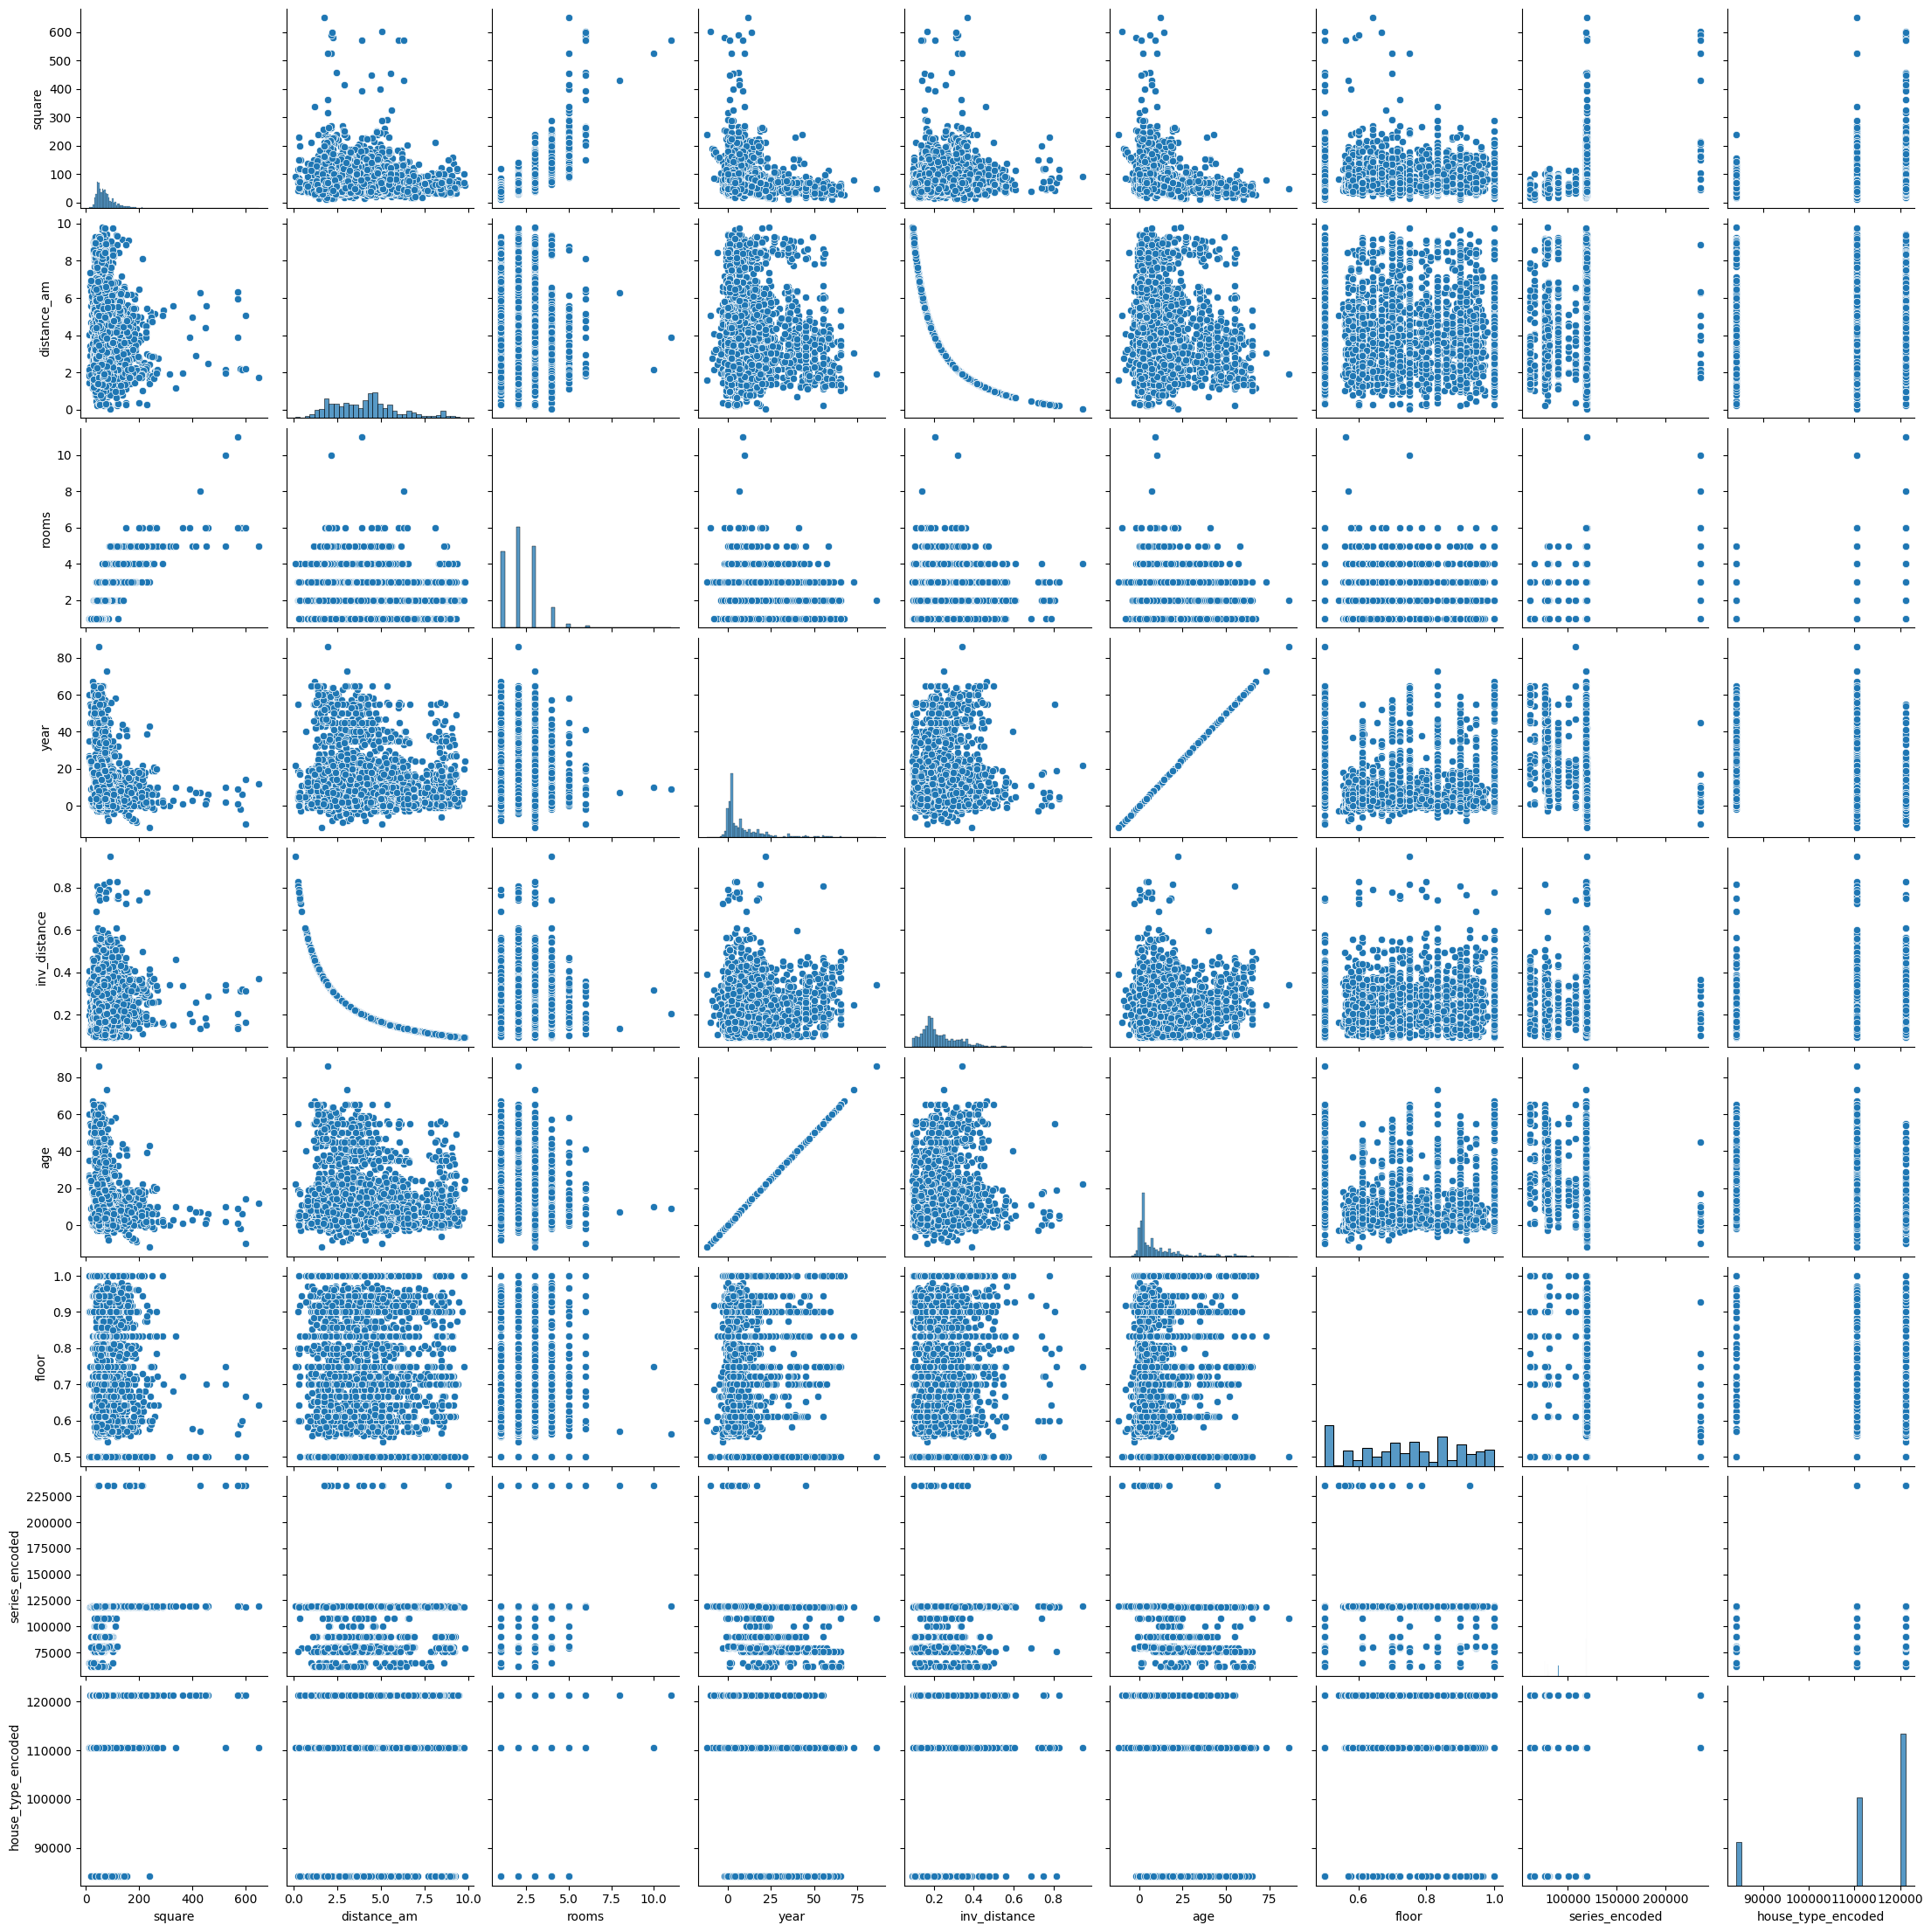

In [ ]:
sns.pairplot(X_train_encoded)

In [ ]:
X_train_encoded.drop(['age', 'house_type_encoded'], axis = 1, inplace = True)
X_test_encoded.drop(['age', 'house_type_encoded'], axis = 1, inplace = True)